In [2]:

import os
import re
import string
import warnings
import pickle
from collections import Counter
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline


import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk import FreqDist, ngrams


nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')


import spacy
nlp = spacy.load("en_core_web_sm")


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import (
    CountVectorizer,      # Bag of Words + N-gram
    TfidfVectorizer       # TF-IDF
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

from gensim.models import Word2Vec, KeyedVectors
from gensim.models.doc2vec import Doc2Vec, TaggedDocument


import tensorflow as tf
%pip install gensim

import os
import re
import string
import warnings
import pickle
from collections import Counter
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline


import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk import FreqDist, ngrams


nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')


import spacy
nlp = spacy.load("en_core_web_sm")


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import (
    CountVectorizer,      
    TfidfVectorizer       
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix
)

from gensim.models import Word2Vec, KeyedVectors
from gensim.models.doc2vec import Doc2Vec, TaggedDocument


import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, LSTM, GRU, Bidirectional,
    Dense, Dropout, GlobalMaxPooling1D,
    Conv1D, MaxPooling1D, Input, Flatten
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical


import datetime

print("All imports loaded successfully!")
print(f"   TensorFlow version : {tf.__version__}")
print(f"   NumPy version      : {np.__version__}")
print(f"   Pandas version     : {pd.__version__}")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\omare\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\omare\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\omare\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\omare\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\omare\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Note: you may need to restart the kernel to use updated packages.


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\omare\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\omare\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\omare\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\omare\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\omare\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


All imports loaded successfully!
   TensorFlow version : 2.20.0
   NumPy version      : 2.2.6
   Pandas version     : 2.3.3


In [3]:

true_df = pd.read_csv(r"D:\DEPI R4 AI\Data Sets\True.csv")
fake_df = pd.read_csv(r"D:\DEPI R4 AI\Data Sets\Fake.csv")


true_df['label'] = 1   # Real = 1
fake_df['label'] = 0   # Fake = 0


df = pd.concat([true_df, fake_df], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle

print(f"Total samples   : {len(df)}")
print(f"True news       : {(df['label']==1).sum()}")
print(f"Fake news       : {(df['label']==0).sum()}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Total samples   : 44898
True news       : 21417
Fake news       : 23481

Columns: ['title', 'WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal conservative” on Sunday and urged budget restraint in 2018. In keeping with a sharp pivot under way among Republicans, U.S. Representative Mark Meadows, speaking on CBS’ “Face the Nation,” drew a hard line on federal spending, which lawmakers are bracing to do battle over in January. When they return from the holidays on Wednesday, lawmakers will begin trying to pass a federal budget in a fight likely to be linked to other issues, such as immigration policy, even as the November congressional election campaigns approach in which Republicans will seek to keep control of Congress. President Donald Trump and his Republicans want a big budget increase in military spending, while Democrats also want pro

title  \
0   BREAKING: GOP Chairman Grassley Has Had Enoug...   
1  Failed GOP Candidates Remembered In Hilarious ...   
2  Mike Pence’s New DC Neighbors Are HILARIOUSLY ...   
3  California AG pledges to defend birth control ...   
4  AZ RANCHERS Living On US-Mexico Border Destroy...   

  WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal conservative” on Sunday and urged budget restraint in 2018. In keeping with a sharp pivot under way among Republicans, U.S. Representative Mark Meadows, speaking on CBS’ “Face the Nation,” drew a hard line on federal spending, which lawmakers are bracing to do battle over in January. When they return from the holidays on Wednesday, lawmakers will begin trying to pass a federal budget in a fight likely to be linked to other issues, such as immigration policy, even as the November congressional election campaigns approach in which Republicans will seek to keep control of Congress. President Donald Trump and his Republicans want a big budget increase in military spending, while Democrats also want proportional increases for non-defense “discretionary” spending on programs that support education, scientific research, infrastructure, public health and environmental protection. “The (Trump) administration has already been willing to say: ‘We’re going to increase non-defense discretionary spending ... by about 7 percent,’” Meadows, chairman of the small but influential House Freedom Caucus, said on the program. “Now, Democrats are saying that’s not enough, we need to give the government a pay raise of 10 to 11 percent. For a fiscal conservative, I don’t see where the rationale is. ... Eventually you run out of other people’s money,” he said. Meadows was among Republicans who voted in late December for their party’s debt-financed tax overhaul, which is expected to balloon the federal budget deficit and add about $1.5 trillion over 10 years to the $20 trillion national debt. “It’s interesting to hear Mark talk about fiscal responsibility,” Democratic U.S. Representative Joseph Crowley said on CBS. Crowley said the Republican tax bill would require the  United States to borrow $1.5 trillion, to be paid off by future generations, to finance tax cuts for corporations and the rich. “This is one of the least ... fiscally responsible bills we’ve ever seen passed in the history of the House of Representatives. I think we’re going to be paying for this for many, many years to come,” Crowley said. Republicans insist the tax package, the biggest U.S. tax overhaul in more than 30 years,  will boost the economy and job growth. House Speaker Paul Ryan, who also supported the tax bill, recently went further than Meadows, making clear in a radio interview that welfare or “entitlement reform,” as the party often calls it, would be a top Republican priority in 2018. In Republican parlance, “entitlement” programs mean food stamps, housing assistance, Medicare and Medicaid health insurance for the elderly, poor and disabled, as well as other programs created by Washington to assist the needy. Democrats seized on Ryan’s early December remarks, saying they showed Republicans would try to pay for their tax overhaul by seeking spending cuts for social programs. But the goals of House Republicans may have to take a back seat to the Senate, where the votes of some Democrats will be needed to approve a budget and prevent a government shutdown. Democrats will use their leverage in the Senate, which Republicans narrowly control, to defend both discretionary non-defense programs and social spending, while tackling the issue of the “Dreamers,” people brought illegally to the country as children. Trump in September put a March 2018 expiration date on the Deferred Action for Childhood Arrivals, or DACA, program, which protects the young immigrants from deportation and provides them wi

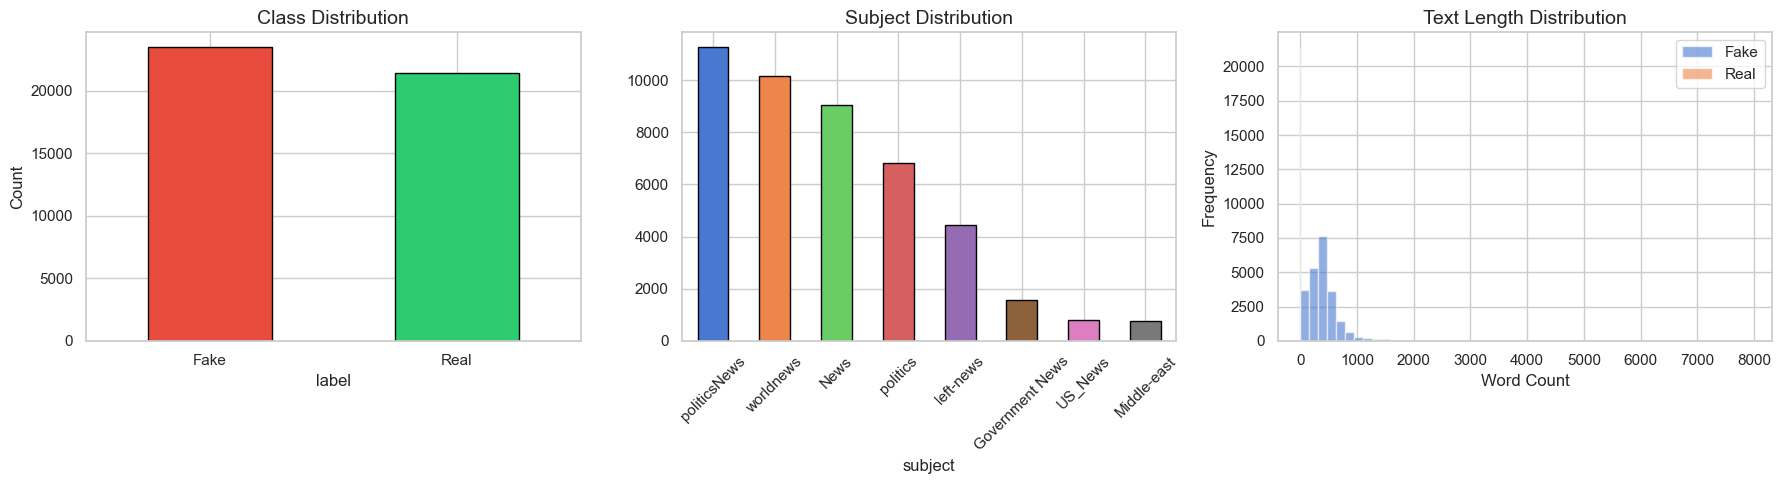

count    44898.000000
mean       221.455054
std        359.024374
min          1.000000
25%          1.000000
50%         17.000000
75%        373.000000
max       7928.000000
Name: text_length, dtype: float64


In [4]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


df['label'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14)
axes[0].set_xticklabels(['Fake', 'Real'], rotation=0)
axes[0].set_ylabel('Count')

df['subject'].value_counts().plot(kind='bar', ax=axes[1],
    color=sns.color_palette('muted'), edgecolor='black')
axes[1].set_title('Subject Distribution', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))
df.groupby('label')['text_length'].plot(kind='hist', bins=50,
    alpha=0.6, ax=axes[2], legend=True)
axes[2].set_title('Text Length Distribution', fontsize=14)
axes[2].set_xlabel('Word Count')
axes[2].legend(['Fake', 'Real'])

plt.tight_layout()
plt.show()

print(df['text_length'].describe())

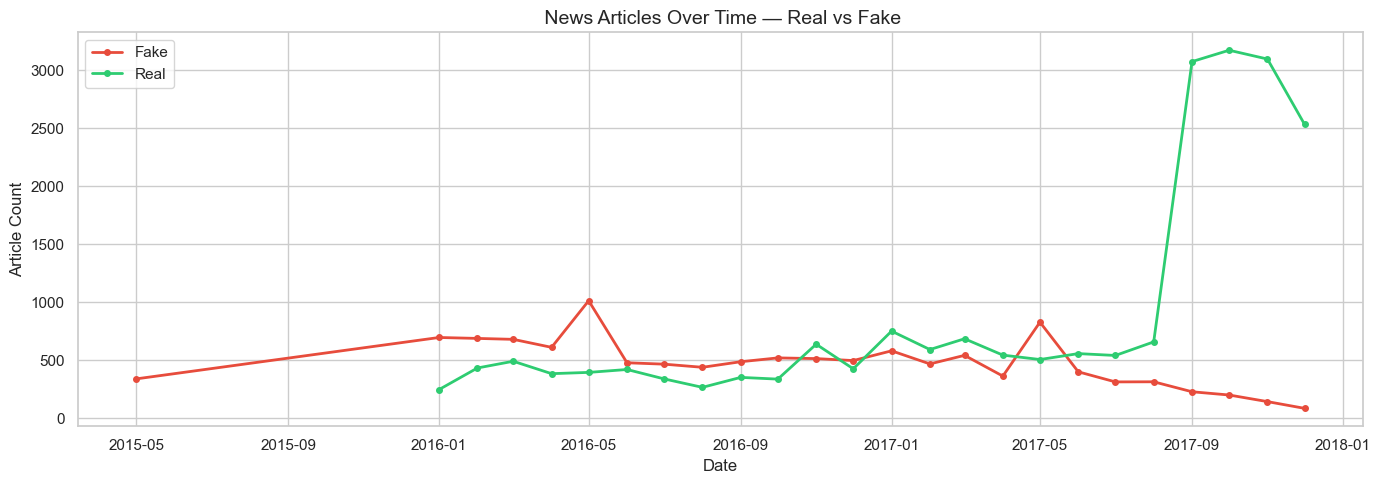

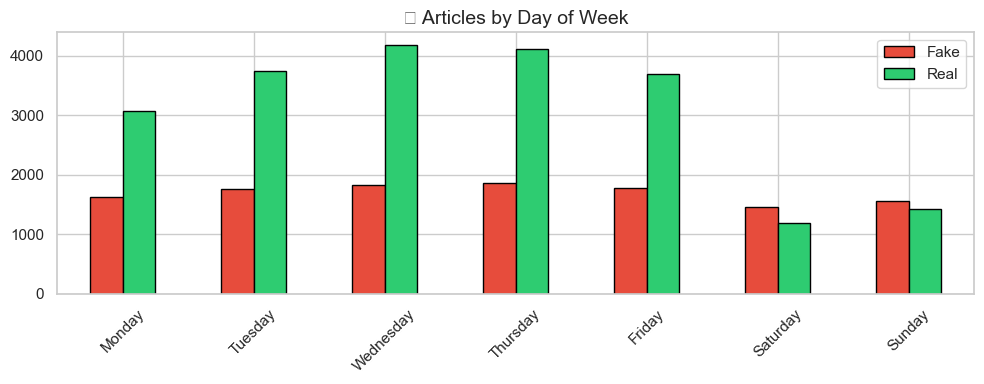

In [5]:

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day']   = df['date'].dt.day_name()


monthly = df.groupby(['year', 'month', 'label']).size().reset_index(name='count')
monthly['period'] = pd.to_datetime(
    monthly['year'].astype(str) + '-' + monthly['month'].astype(str))

fig, ax = plt.subplots(figsize=(14, 5))
for label, color, name in zip([0,1], ['#e74c3c','#2ecc71'], ['Fake','Real']):
    subset = monthly[monthly['label']==label]
    ax.plot(subset['period'], subset['count'],
            label=name, color=color, linewidth=2, marker='o', markersize=4)

ax.set_title(' News Articles Over Time — Real vs Fake', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Article Count')
ax.legend()
plt.tight_layout()
plt.show()


day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
fig, ax = plt.subplots(figsize=(10, 4))
df_day = df.groupby(['day', 'label']).size().unstack().reindex(day_order)
df_day.plot(kind='bar', ax=ax, color=['#e74c3c','#2ecc71'], edgecolor='black')
ax.set_title('📆 Articles by Day of Week', fontsize=14)
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
ax.legend(['Fake', 'Real'])
plt.tight_layout()
plt.show()

In [6]:

lemmatizer  = WordNetLemmatizer()
stemmer     = PorterStemmer()
stop_words  = set(stopwords.words('english'))

# Add domain-specific stopwords
extra_stops = {'reuters', 'said', 'say', 'would', 'also', 'one', 'u', 'us', 'mr'}
stop_words.update(extra_stops)


def preprocess_text(text, use_lemma=True, remove_stops=True):
    """
    Full NLP preprocessing pipeline:
    1. Lowercase
    2. Remove URLs, HTML, special chars, numbers
    3. Tokenization
    4. Stopword removal
    5. Lemmatization OR Stemming
    """
    if pd.isnull(text):
        return ""

    text = text.lower()

    text = re.sub(r'http\S+|www\S+', '', text)        # URLs
    text = re.sub(r'<.*?>', '', text)                   # HTML tags
    text = re.sub(r'\[.*?\]', '', text)                 # Brackets
    text = re.sub(r'[^a-z\s]', '', text)               # Keep only letters
    text = re.sub(r'\s+', ' ', text).strip()            # Extra spaces

    # 3. Tokenization
    tokens = word_tokenize(text)


    if remove_stops:
        tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    if use_lemma:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    else:
        tokens = [stemmer.stem(t) for t in tokens]

    return ' '.join(tokens)


print("Preprocessing text... (this may take a moment)")
df['text_clean'] = df['text'].apply(preprocess_text)
df['title_clean'] = df['title'].apply(preprocess_text)


df['combined'] = df['title_clean'] + ' ' + df['text_clean']

print(" Done!")
print("\n--- Original ---")
print(df['text'].iloc[0][:300])
print("\n--- Cleaned ---")
print(df['text_clean'].iloc[0][:300])

Preprocessing text... (this may take a moment)
 Done!

--- Original ---
Donald Trump s White House is in chaos, and they are trying to cover it up. Their Russia problems are mounting by the hour, and they refuse to acknowledge that there are problems surrounding all of this. To them, it s  fake news,  or a  hoax.  However, the facts bear things out differently, and it s

--- Cleaned ---
donald trump white house chaos trying cover russia problem mounting hour refuse acknowledge problem surrounding fake news hoax however fact bear thing differently seems crack congressional public leadershipchuck grassley riowa head senate judiciary committee fed demanding donald trump former trump c


 Token Count Statistics:
         count    mean     std  min    25%    50%    75%     max
label                                                           
0      11868.0  249.31  230.96  0.0  168.0  207.0  267.0  4475.0
1      21417.0    0.00    0.00  0.0    0.0    0.0    0.0     0.0


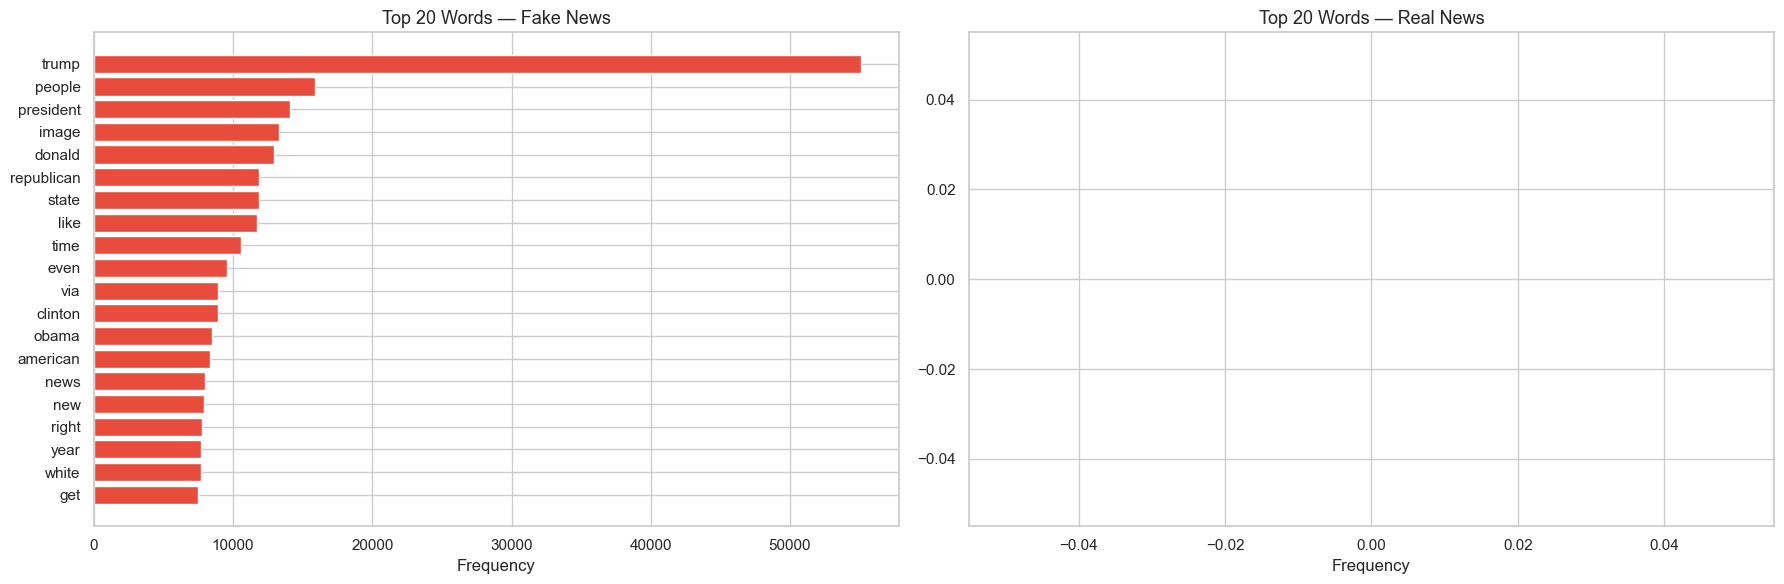

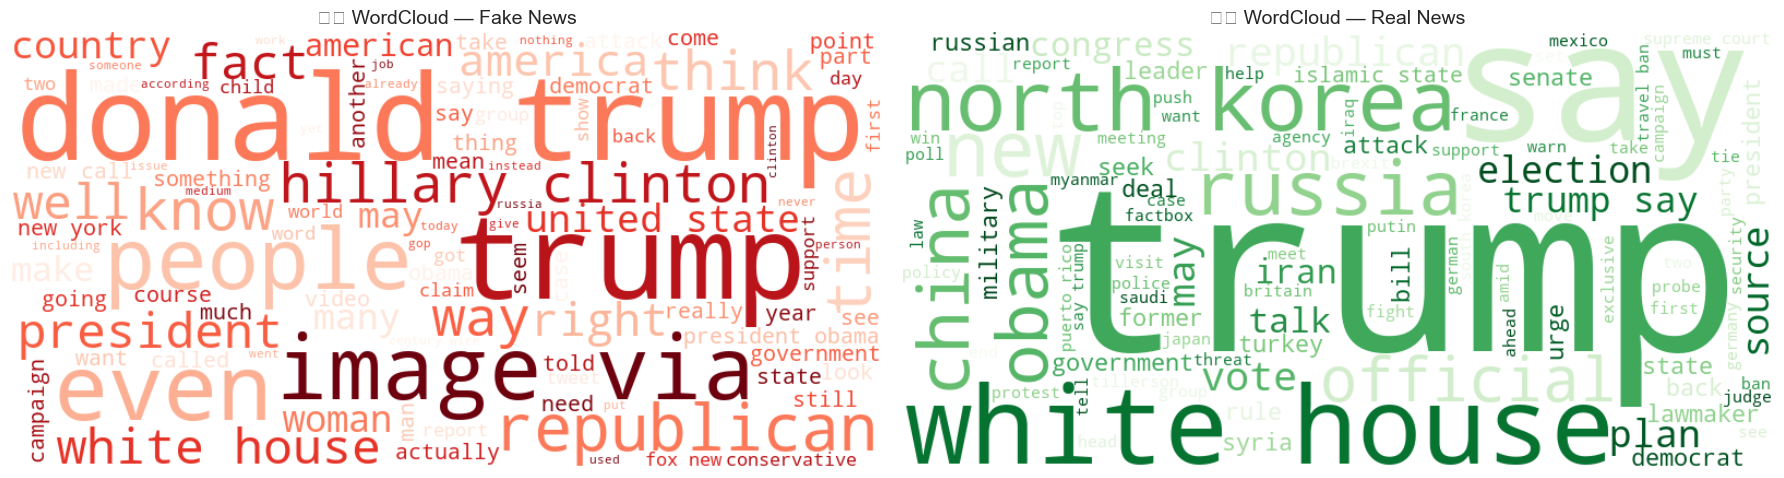

In [7]:
df['token_list']  = df['text_clean'].apply(word_tokenize)
df['token_count'] = df['token_list'].apply(len)

print(" Token Count Statistics:")
print(df.groupby('label')['token_count'].describe().round(2))

# Most Frequent Words per Class 
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for idx, (label, name) in enumerate(zip([0,1], ['Fake News','Real News'])):
    all_tokens = [t for tokens in df[df['label']==label]['token_list']
                  for t in tokens]
    freq = FreqDist(all_tokens)
    top_words = freq.most_common(20)
    if top_words:
        words, counts = zip(*top_words)
    else:
        words, counts = [], []

    axes[idx].barh(words[::-1], counts[::-1],
                   color='#e74c3c' if label==0 else '#2ecc71')
    axes[idx].set_title(f'Top 20 Words — {name}', fontsize=13)
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

#  WordClouds 
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for idx, (label, name, color) in enumerate(zip(
        [0, 1], ['Fake News', 'Real News'], ['Reds', 'Greens'])):
    text_corpus = ' '.join(df[df['label']==label]['text_clean'])
    text_corpus = ' '.join(df[df['label']==label]['combined'])
    if text_corpus.strip():
        wc = WordCloud(width=800, height=400, background_color='white',
                       colormap=color, max_words=100).generate(text_corpus)
    else:
        # If no text, create an empty word cloud or skip
        wc = WordCloud(width=800, height=400, background_color='white').generate("No data")
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f'☁️ WordCloud — {name}', fontsize=14)

plt.tight_layout()
plt.show()

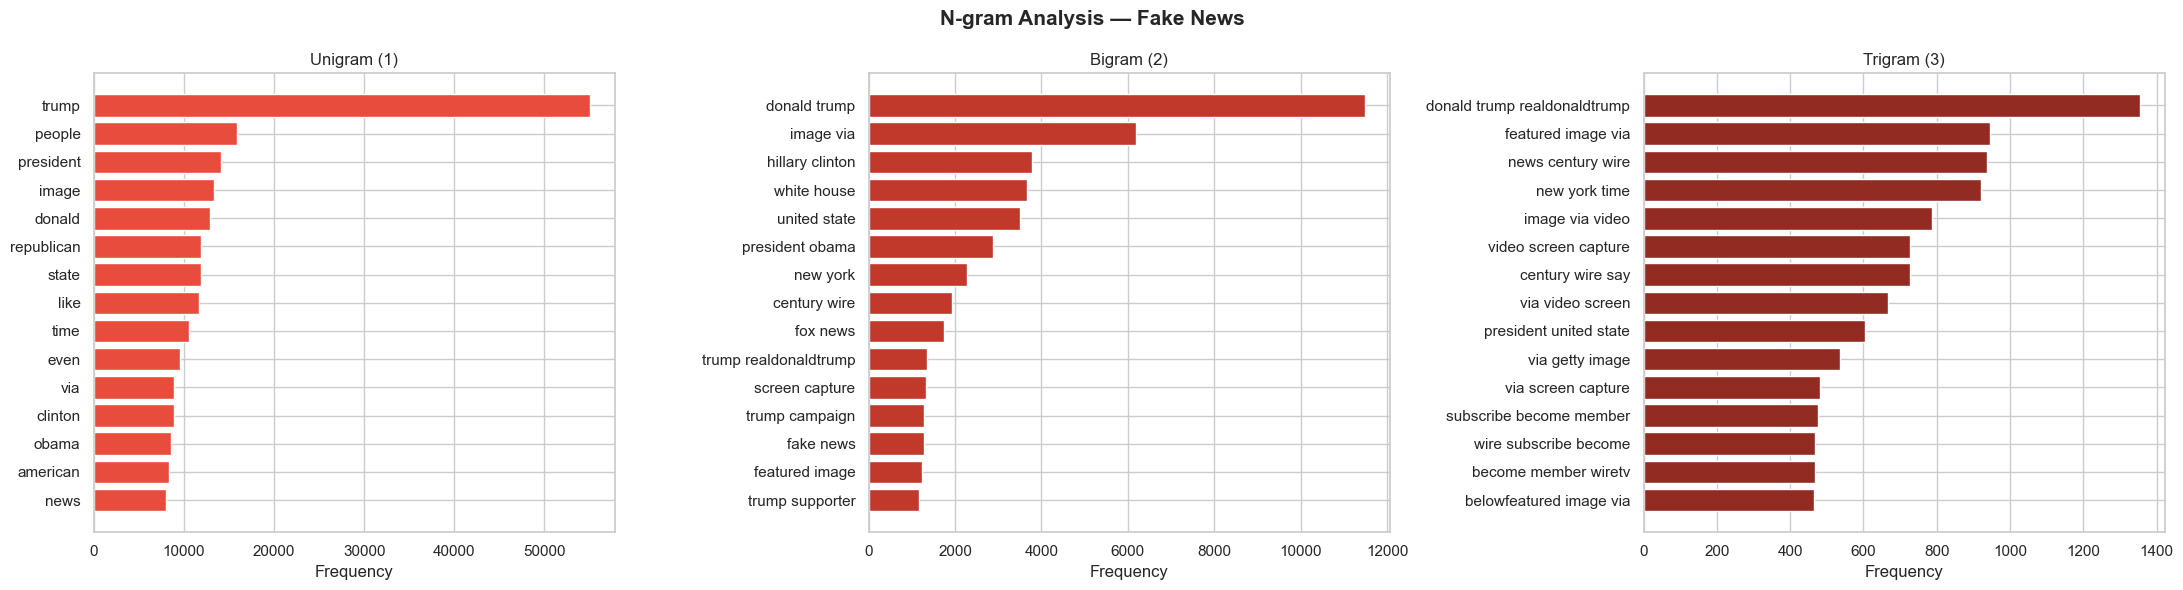

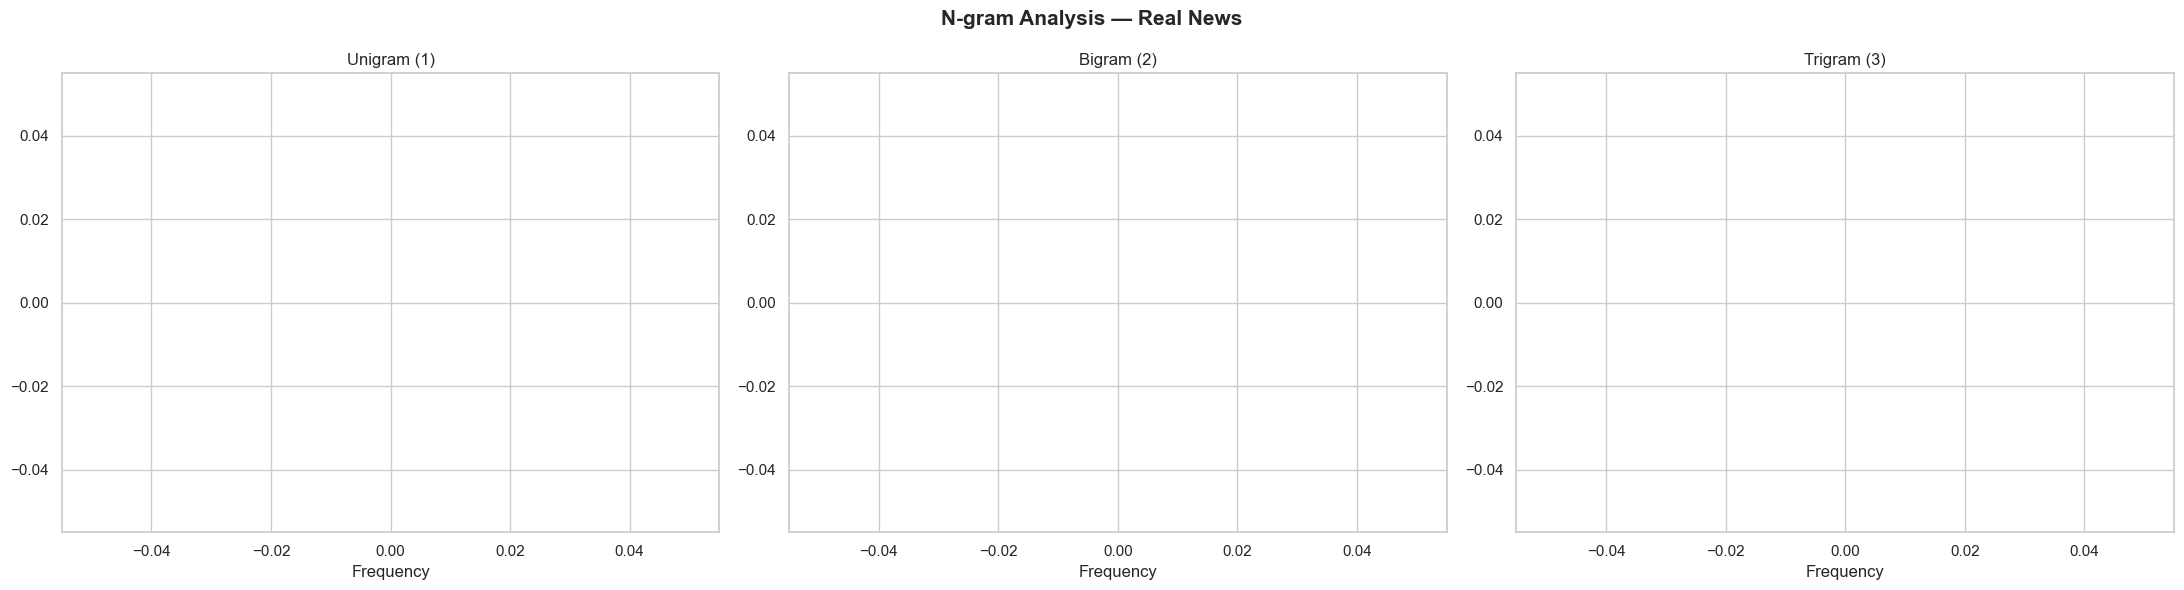

In [8]:
def get_top_ngrams(corpus_tokens, n=2, top_k=20):
    """Extract top-k n-grams from a list of token lists."""
    all_ngrams = []
    for tokens in corpus_tokens:
        all_ngrams.extend(list(ngrams(tokens, n)))
    counter = Counter(all_ngrams)
    return counter.most_common(top_k)

def plot_ngrams(ngram_list, title, color, ax):
    labels = [' '.join(g) for g, _ in ngram_list]
    values = [c for _, c in ngram_list]
    ax.barh(labels[::-1], values[::-1], color=color)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Frequency')

# ─── Compute N-grams ─────────────────────────────────────────────────────────
for label, name, colors in zip(
        [0, 1],
        ['Fake News', 'Real News'],
        [['#e74c3c','#c0392b','#922b21'],
         ['#2ecc71','#27ae60','#1e8449']]):

    tokens_list = df[df['label']==label]['token_list'].tolist()
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    fig.suptitle(f'N-gram Analysis — {name}', fontsize=15, fontweight='bold')

    for n, ax, color, gram_name in zip(
            [1, 2, 3], axes, colors,
            ['Unigram (1)', 'Bigram (2)', 'Trigram (3)']):
        top = get_top_ngrams(tokens_list, n=n, top_k=15)
        plot_ngrams(top, gram_name, color, ax)

    plt.tight_layout()
    plt.show()

In [9]:
# ─── Train/Test Split 
X = df['combined']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# ─── Bag of Words 
bow_vectorizer = CountVectorizer(
    max_features=20000,
    min_df=2,
    max_df=0.95
)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow  = bow_vectorizer.transform(X_test)

print(f"   BoW Matrix Shape:")
print(f"   Train : {X_train_bow.shape}")
print(f"   Test  : {X_test_bow.shape}")
print(f"   Vocabulary Size: {len(bow_vectorizer.vocabulary_)}")
print(f"Sample vocab: {list(bow_vectorizer.vocabulary_.keys())[:15]}")

Train: 26628 | Test: 6657
   BoW Matrix Shape:
   Train : (26628, 20000)
   Test  : (6657, 20000)
   Vocabulary Size: 20000
Sample vocab: ['identity', 'arrested', 'antiracist', 'stone', 'mountain', 'protester', 'released', 'video', 'authority', 'nine', 'men', 'april', 'clash', 'dozen', 'white']


   TF-IDF Shapes:
  Unigram — Train: (26628, 20000) | Test: (6657, 20000)
  Bigram  — Train: (26628, 20000) | Test: (6657, 20000)


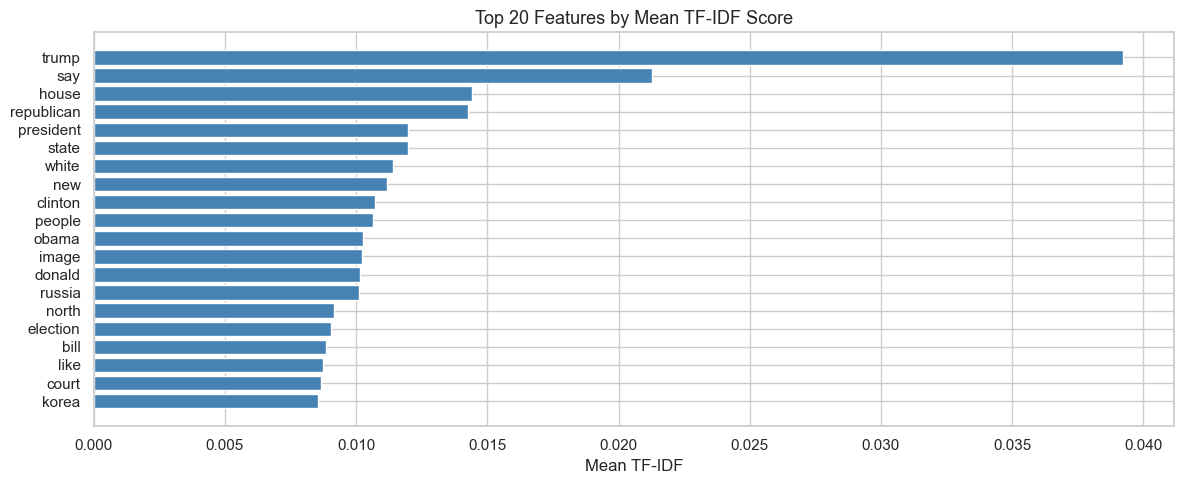

In [10]:
# ─── TF-IDF (Unigram) 
tfidf_uni = TfidfVectorizer(
    max_features=20000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf_uni.fit_transform(X_train)
X_test_tfidf  = tfidf_uni.transform(X_test)

# ─── TF-IDF (Bigram) 
tfidf_bi = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf_bi = tfidf_bi.fit_transform(X_train)
X_test_tfidf_bi  = tfidf_bi.transform(X_test)

print("   TF-IDF Shapes:")
print(f"  Unigram — Train: {X_train_tfidf.shape} | Test: {X_test_tfidf.shape}")
print(f"  Bigram  — Train: {X_train_tfidf_bi.shape} | Test: {X_test_tfidf_bi.shape}")

# ─── Top TF-IDF Features 
feature_names = np.array(tfidf_uni.get_feature_names_out())
mean_tfidf    = np.asarray(X_train_tfidf.mean(axis=0)).flatten()
top_indices   = mean_tfidf.argsort()[-20:][::-1]

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(feature_names[top_indices][::-1],
        mean_tfidf[top_indices][::-1], color='steelblue')
ax.set_title('Top 20 Features by Mean TF-IDF Score', fontsize=13)
ax.set_xlabel('Mean TF-IDF')
plt.tight_layout()
plt.show()

In [11]:
# ─── One-Hot Encoding via CountVectorizer 
ohe_vectorizer = CountVectorizer(
    max_features=10000,
    binary=True         
)

X_train_ohe = ohe_vectorizer.fit_transform(X_train)
X_test_ohe  = ohe_vectorizer.transform(X_test)

print("  One-Hot Encoding Shape:")
print(f"   Train : {X_train_ohe.shape}")
print(f"   Test  : {X_test_ohe.shape}")

# ─── Label One Hot encoding 
y_train_ohe = to_categorical(y_train, num_classes=2)
y_test_ohe  = to_categorical(y_test,  num_classes=2)

print(f"\n   Label shape (train): {y_train_ohe.shape}")
print(f"   Sample: {y_train_ohe[:5]}")

  One-Hot Encoding Shape:
   Train : (26628, 10000)
   Test  : (6657, 10000)

   Label shape (train): (26628, 2)
   Sample: [[1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]]


In [12]:
# ─── Prepare Token Lists 
train_tokens = df.loc[X_train.index, 'token_list'].tolist()
test_tokens  = df.loc[X_test.index,  'token_list'].tolist()

# ─── Train Word2Vec 
w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,      # Embedding dimensions
    window=5,             # Context window
    min_count=2,          # Ignore rare words
    workers=4,
    epochs=10,
    sg=1                  
)

print(f"   Word2Vec trained!")
print(f"   Vocabulary size : {len(w2v_model.wv)}")

test_words = ['trump', 'election', 'president', 'fake', 'russia']
for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f"   Most similar to '{word}':")
        for w, score in similar:
            print(f"   {w:<20} {score:.4f}")


def tokens_to_vector(tokens, model, vector_size=100):
    """Average Word2Vec vectors for all tokens in a document."""
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    if vecs:
        return np.mean(vecs, axis=0)
    return np.zeros(vector_size)

X_train_w2v = np.vstack([tokens_to_vector(t, w2v_model) for t in train_tokens])
X_test_w2v  = np.vstack([tokens_to_vector(t, w2v_model) for t in test_tokens])

print(f"   W2V Document Vectors Shape:")
print(f"   Train: {X_train_w2v.shape} | Test: {X_test_w2v.shape}")

   Word2Vec trained!
   Vocabulary size : 47421
   Most similar to 'trump':
   donald               0.8567
   flirted              0.7951
   himtrump             0.7904
   undeserved           0.7889
   trumpof              0.7846
   Most similar to 'election':
   electionthe          0.7106
   electionnot          0.6870
   rigging              0.6834
   invalidated          0.6805
   electoral            0.6693
   Most similar to 'president':
   matelol              0.7473
   barack               0.7363
   presidentbut         0.7284
   obama                0.7184
   historypresident     0.7136
   Most similar to 'fake':
   news                 0.7535
   libelous             0.6961
   newsnot              0.6866
   hash                 0.6856
   macedonia            0.6838
   Most similar to 'russia':
   russian              0.7895
   putin                0.7439
   meddling             0.7163
   interfered           0.7074
   meddled              0.6825
   W2V Document Vectors Shape:

   Keras Tokenizer ready:
   Vocab size  : 30000
   Train shape : (26628, 300)
   Test shape  : (6657, 300)


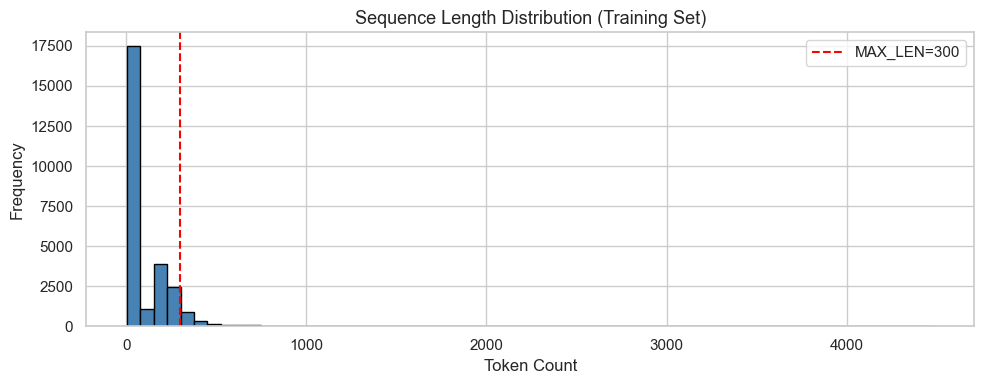

In [13]:

MAX_VOCAB  = 30000
MAX_LEN    = 300

keras_tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
keras_tokenizer.fit_on_texts(X_train)

X_train_seq = keras_tokenizer.texts_to_sequences(X_train)
X_test_seq  = keras_tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN,
                             padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN,
                             padding='post', truncating='post')

VOCAB_SIZE = min(MAX_VOCAB, len(keras_tokenizer.word_index) + 1)

print(f"   Keras Tokenizer ready:")
print(f"   Vocab size  : {VOCAB_SIZE}")
print(f"   Train shape : {X_train_pad.shape}")
print(f"   Test shape  : {X_test_pad.shape}")


seq_lengths = [len(s) for s in X_train_seq]
plt.figure(figsize=(10, 4))
plt.hist(seq_lengths, bins=60, color='steelblue', edgecolor='black')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
plt.title('Sequence Length Distribution (Training Set)', fontsize=13)
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
EMBED_DIM = 100

embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))

word_index = keras_tokenizer.word_index
hits, misses = 0, 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
        hits += 1
    else:
        misses += 1

print(f"   Embedding Matrix: {embedding_matrix.shape}")
print(f"   Words with W2V vectors : {hits}")
print(f"   Words without vectors  : {misses}")
print(f"   Coverage               : {hits/(hits+misses)*100:.1f}%")

   Embedding Matrix: (30000, 100)
   Words with W2V vectors : 29550
   Words without vectors  : 449
   Coverage               : 98.5%


In [15]:
def build_lstm(vocab_size, embed_dim, embed_matrix, max_len,
               trainable=False):
    model = Sequential([
        Embedding(input_dim=vocab_size,
                  output_dim=embed_dim,
                  weights=[embed_matrix],
                  input_length=max_len,
                  trainable=trainable,
                  name='embedding'),
        Bidirectional(LSTM(128, return_sequences=True), name='bilstm_1'),
        Dropout(0.3),
        Bidirectional(LSTM(64), name='bilstm_2'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ], name='BiLSTM_W2V')

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

lstm_model = build_lstm(VOCAB_SIZE, EMBED_DIM, embedding_matrix, MAX_LEN)
lstm_model.summary()

Model: "BiLSTM_W2V"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000,000 (11.44 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,000,000 (11.44 MB)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 768s 2s/step - accuracy: 0.9937 - loss: 0.0233 - val_accuracy: 0.9985 - val_loss: 0.0090
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 694s 2s/step - accuracy: 0.9987 - loss: 0.0052 - val_accuracy: 0.9974 - val_loss: 0.0083
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 841s 2s/step - accuracy: 0.9991 - loss: 0.0029 - val_accuracy: 0.9989 - val_loss: 0.0052
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 737s 2s/step - accuracy: 0.9995 - loss: 0.0016 - val_accuracy: 0.9985 - val_loss: 0.0057
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 719s 2s/step - accuracy: 0.9996 - loss: 0.0013 - val_accuracy: 0.9985 - val_loss: 0.0119
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 745s 2s/step - accuracy: 0.9995 - loss: 0.0019 - val_accuracy: 0.9992 - val_loss: 0.0044
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 822s 2s/step - accuracy: 0.9998 - loss: 0.0011 - val_accuracy: 0.9989 - val_loss: 0.0051
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 924s 2s/step - accuracy: 0.9997 - loss: 0.0012 - val_accu

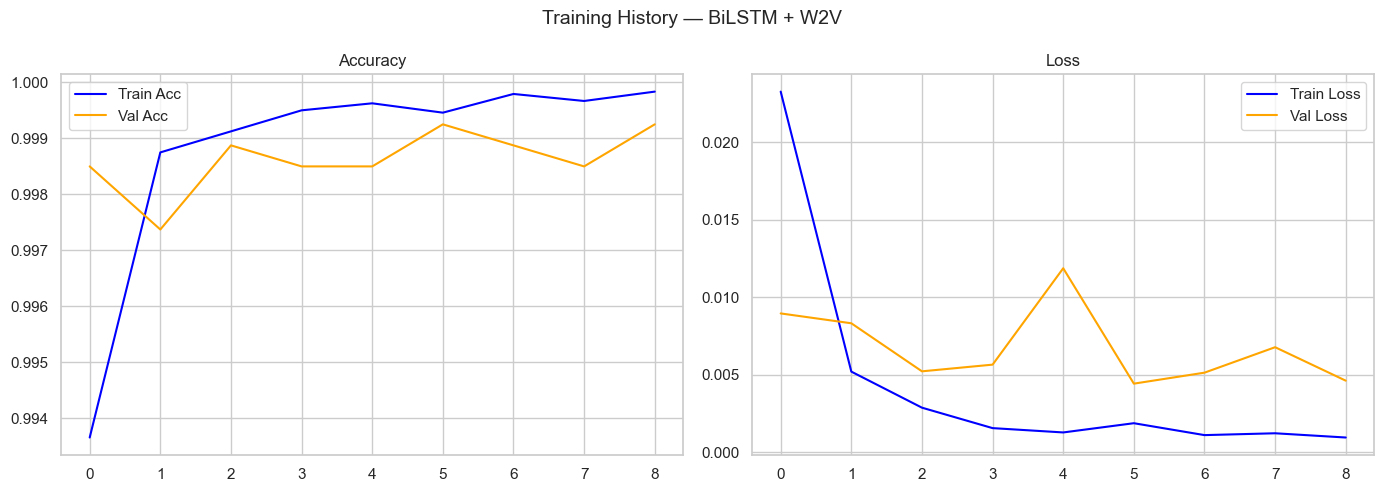

In [16]:
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'),
    ModelCheckpoint('best_lstm.keras', save_best_only=True, monitor='val_accuracy')
]

history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

# ─── Plot Training History ────────────────────────────────────────────────────
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Training History — {model_name}', fontsize=14)

    axes[0].plot(history.history['accuracy'],     label='Train Acc',  color='blue')
    axes[0].plot(history.history['val_accuracy'], label='Val Acc',    color='orange')
    axes[0].set_title('Accuracy')
    axes[0].legend()

    axes[1].plot(history.history['loss'],     label='Train Loss', color='blue')
    axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange')
    axes[1].set_title('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history_lstm, 'BiLSTM + W2V')